# Chapter 17 - De Rham Cohomology

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `440-466`.

**Chapter Goal.** Build a standalone route from closed and exact forms to global cohomology invariants: induced maps, homotopy invariance, Poincare lemma, Mayer-Vietoris computations, top-degree cohomology, and degree theory.

The chapter starts from a simple obstruction: a closed form can fail to be exact because a loop or higher-dimensional cycle detects a hole. The notebook makes that obstruction inspectable. We will keep two complementary models in view. The smooth model uses differential forms, pullbacks, integration, Stokes's theorem, and partitions of unity. The finite model uses small cochain complexes to show the same algebraic pattern: closed means "lands in the next kernel"; exact means "comes from the previous image"; cohomology measures what is closed but not exact.

Nothing here is copied from the text. The source pages determine the concept order and theorem coverage; the examples, diagrams, and computations below are original notebook models chosen to make the chapter learnable without keeping the book open.

## Visual Storyboard

| Chapter idea | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- |
| de Rham complex and functoriality | proof dependency graph | NetworkX, Matplotlib | where `d^2=0`, pullback, homotopy, and Stokes enter | graph has the required theorem anchors |
| closed versus exact | punctured-plane angular form | SymPy, NumPy, Matplotlib | a closed local form with nonzero loop integral | symbolic `d omega = 0`, numeric integral `2*pi` |
| homotopy invariance | cylinder/homotopy operator diagram | SymPy, Matplotlib | why `i_1^* - i_0^*` is a coboundary on cohomology | `h(dg)=g(1)-g(0)` in a test case |
| cohomology as linear algebra | finite cochain models for interval, circle, disk | NumPy, Matplotlib | which closed cochains fail to be exact | Betti numbers match the visible holes |
| Mayer-Vietoris | two-arc cover of `S^1` | NumPy, Matplotlib | the connecting map that recovers the missing `H^1` | rank/cokernel dimensions give one generator |
| top degree and compact support | comparison table | CSV/JSON | orientability, compactness, and support hypotheses | table records the source-theorem cases |
| degree theory | circle maps `z -> z^k` | NumPy, Matplotlib | integration definition versus signed preimage count | both definitions return `k` |

This chapter is proof-heavy, so several artifacts are proof views rather than surface plots. The finite cochain models are intentionally small; they are not a replacement for de Rham theory, but they expose the quotient algebra that the smooth theory uses.

## Setup

The notebook writes every generated artifact under the book-local `artifacts/chapter-17-de-rham-cohomology/` tree. The helper functions are intentionally small and visible: saving a figure, saving a table, displaying the artifact, and asserting that the final files exist.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
if BOOK_ROOT.name != "Introduction-to-Smooth-Manifolds":
    BOOK_ROOT = next(path for path in [BOOK_ROOT, *BOOK_ROOT.parents] if path.name == "Introduction-to-Smooth-Manifolds")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-17-de-rham-cohomology"
UNIT_TITLE = "De Rham Cohomology"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifacts: list[Path] = []
check_paths: list[Path] = []

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def artifact_record(path: Path) -> dict[str, object]:
    return {
        "path": str(path.relative_to(BOOK_ROOT)).replace("\\", "/"),
        "bytes": path.stat().st_size,
    }

print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifact root: artifacts\chapter-17-de-rham-cohomology


## Library Routing

Matplotlib is enough for the durable diagrams in this chapter because the key objects are complexes, loops, covers, and degree counts. NetworkX is used where the geometry is a proof dependency graph. SymPy checks exact identities for forms and homotopy-operator tests. NumPy supplies small boundary and coboundary matrices for finite analogs of `closed modulo exact`.

## 1. The de Rham Complex As A Proof Map

The central object is a cochain complex:

`Omega^0(M) -> Omega^1(M) -> ... -> Omega^n(M)`, with every consecutive composition zero. Closed forms live in kernels, exact forms live in images, and the quotient `Z^p(M)/B^p(M)` records the failure of exactness.

The source chapter then layers in several transport principles: pullbacks descend to cohomology, diffeomorphisms preserve cohomology, homotopic maps induce the same cohomology map, contractible or star-shaped spaces have no higher cohomology, and Mayer-Vietoris computes groups from a cover. The graph below is a reading map for those dependencies.

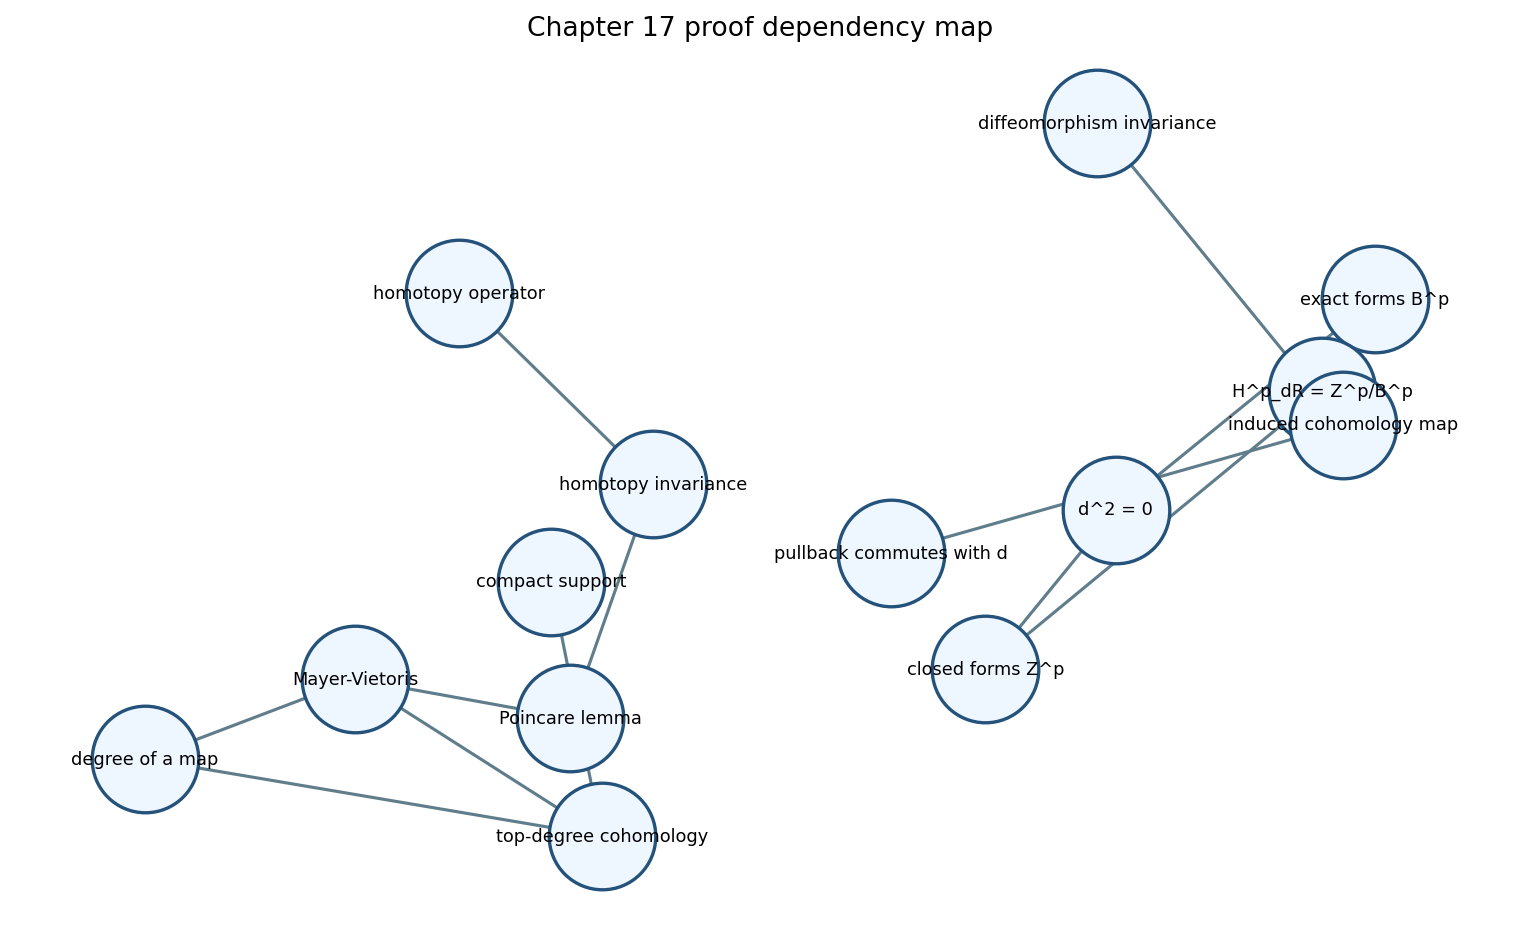

In [2]:
nodes = [
    "d^2 = 0",
    "closed forms Z^p",
    "exact forms B^p",
    "H^p_dR = Z^p/B^p",
    "pullback commutes with d",
    "induced cohomology map",
    "diffeomorphism invariance",
    "homotopy operator",
    "homotopy invariance",
    "Poincare lemma",
    "Mayer-Vietoris",
    "compact support",
    "top-degree cohomology",
    "degree of a map",
]
edges = [
    ("d^2 = 0", "exact forms B^p"),
    ("d^2 = 0", "closed forms Z^p"),
    ("closed forms Z^p", "H^p_dR = Z^p/B^p"),
    ("exact forms B^p", "H^p_dR = Z^p/B^p"),
    ("pullback commutes with d", "induced cohomology map"),
    ("induced cohomology map", "diffeomorphism invariance"),
    ("homotopy operator", "homotopy invariance"),
    ("homotopy invariance", "Poincare lemma"),
    ("Poincare lemma", "Mayer-Vietoris"),
    ("Mayer-Vietoris", "top-degree cohomology"),
    ("compact support", "top-degree cohomology"),
    ("top-degree cohomology", "degree of a map"),
    ("Mayer-Vietoris", "degree of a map"),
]
graph = nx.DiGraph()
graph.add_nodes_from(nodes)
graph.add_edges_from(edges)
pos = nx.spring_layout(graph, seed=17, k=0.82)

fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx_edges(graph, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.4, edge_color="#607d8b")
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=2300, node_color="#eef6ff", edgecolors="#24527a", linewidths=1.5)
nx.draw_networkx_labels(graph, pos, ax=ax, font_size=8)
ax.set_title("Chapter 17 proof dependency map")
ax.axis("off")
dependency_path = save_matplotlib(fig, FIGURES / "de-rham-proof-dependency-map.png")
plt.close(fig)
artifacts.append(dependency_path)

dependency_check = save_json(
    {
        "nodes": nodes,
        "edges": edges,
        "required_anchors_present": all(term in nodes for term in ["H^p_dR = Z^p/B^p", "homotopy operator", "Mayer-Vietoris", "degree of a map"]),
        "acyclic": nx.is_directed_acyclic_graph(graph),
    },
    CHECKS / "de-rham-proof-dependency-map.json",
)
check_paths.append(dependency_check)
display_artifact(dependency_path, width=980)

## 2. Closed Does Not Mean Exact: The Angular Form

The punctured plane is the chapter's first mental model for a global obstruction. On `R^2 - {0}`, the angular 1-form

`omega = (-y dx + x dy)/(x^2 + y^2)`

is closed. It is locally the derivative of an angle coordinate, so it looks exact in small charts. Around a loop enclosing the missing point, however, its integral is `2*pi`, so it cannot be globally exact. Stokes's theorem would force the integral of an exact form around a boundaryless compact loop to vanish.

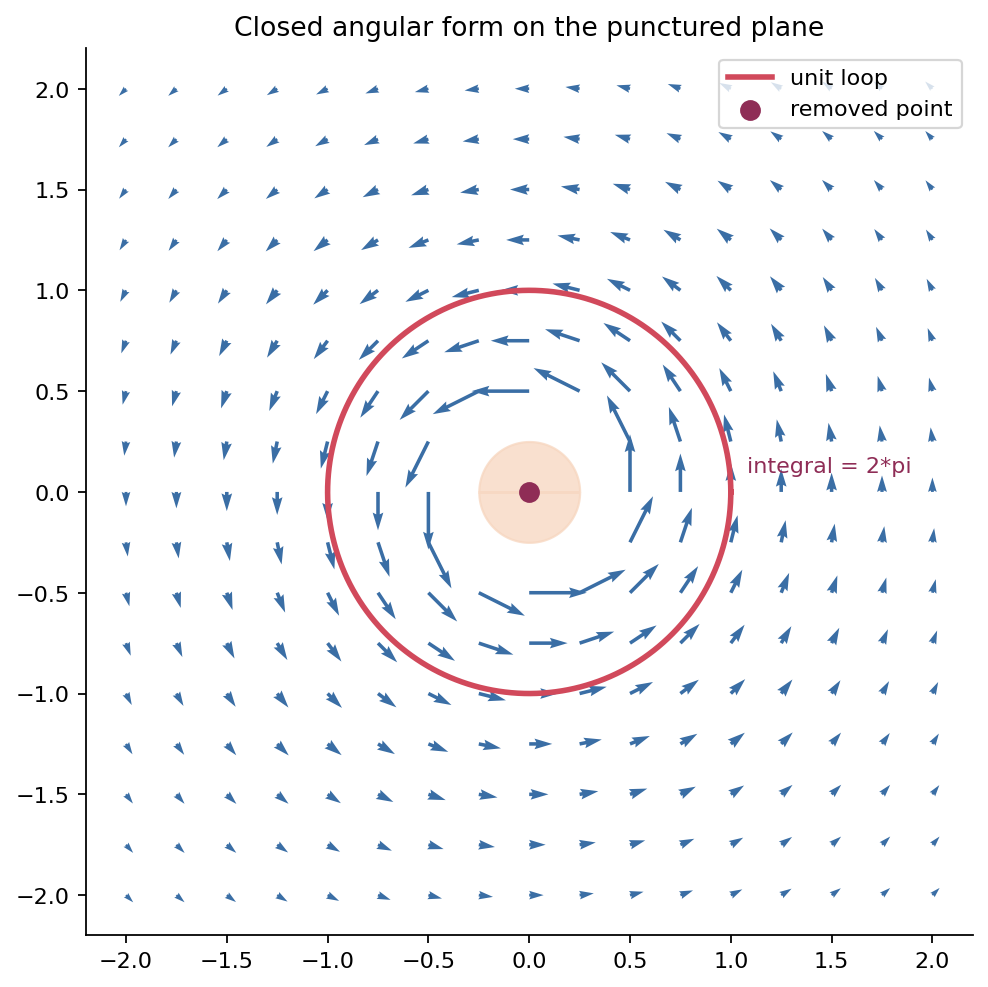

In [3]:
x, y, t = sp.symbols("x y t", real=True)
P = -y / (x**2 + y**2)
Q = x / (x**2 + y**2)
d_omega_coeff = sp.simplify(sp.diff(Q, x) - sp.diff(P, y))

theta = np.linspace(0, 2 * np.pi, 800)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
omega_on_circle = np.ones_like(theta)
loop_integral = float(np.trapezoid(omega_on_circle, theta))

grid = np.linspace(-2.0, 2.0, 17)
X, Y = np.meshgrid(grid, grid)
R2 = X**2 + Y**2
mask = R2 > 0.22
U = np.zeros_like(X)
V = np.zeros_like(Y)
U[mask] = -Y[mask] / R2[mask]
V[mask] = X[mask] / R2[mask]

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.quiver(X[mask], Y[mask], U[mask], V[mask], angles="xy", scale_units="xy", scale=7, color="#3a6ea5", width=0.004)
ax.plot(circle_x, circle_y, color="#d1495b", lw=2.5, label="unit loop")
ax.fill_between(0.25 * np.cos(theta), 0.25 * np.sin(theta), color="#f7d6bf", alpha=0.75)
ax.scatter([0], [0], color="#8f2d56", s=70, zorder=5, label="removed point")
ax.text(1.08, 0.1, "integral = 2*pi", color="#8f2d56")
ax.set_aspect("equal")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_title("Closed angular form on the punctured plane")
ax.legend(loc="upper right")
angular_path = save_matplotlib(fig, FIGURES / "closed-angular-form-nonexact-loop.png")
plt.close(fig)
artifacts.append(angular_path)

angular_check = save_json(
    {
        "d_omega_coefficient": str(d_omega_coeff),
        "loop_integral_numeric": loop_integral,
        "expected_loop_integral": float(2 * np.pi),
        "closed": bool(d_omega_coeff == 0),
        "nonzero_period": bool(abs(loop_integral - 2 * np.pi) < 1e-3),
    },
    CHECKS / "closed-angular-form-nonexact-loop.json",
)
check_paths.append(angular_check)
display_artifact(angular_path, width=720)

## 3. Homotopy Invariance Through A Homotopy Operator

Homotopy invariance is not a slogan; it is driven by a cochain homotopy. If two maps are joined by a smooth homotopy, the difference between their pullbacks on closed forms becomes exact. The proof constructs an operator `h` satisfying

`d h + h d = i_1^* - i_0^*`.

The diagram below treats the interval direction as the mechanism that turns change along the homotopy into a coboundary. The tiny symbolic test uses `M` as a point, so the formula reduces to the fundamental theorem of calculus.

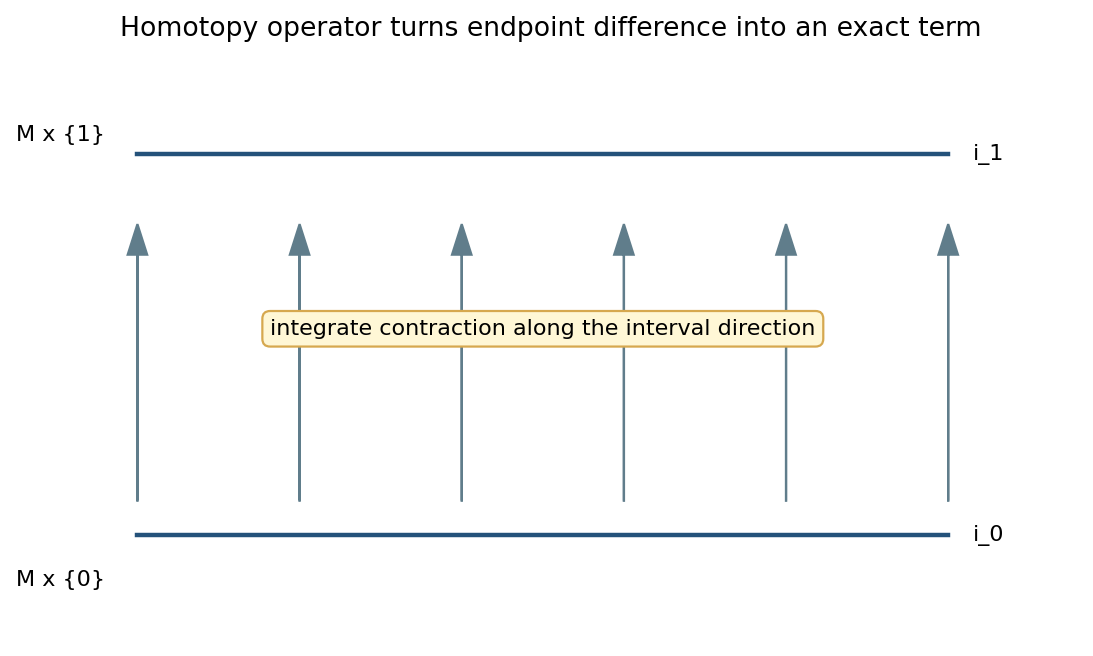

In [4]:
s = sp.symbols("s", real=True)
g = s**3 - 2 * s
dg_ds = sp.diff(g, s)
h_dg = sp.integrate(dg_ds, (s, 0, 1))
endpoint_difference = sp.simplify(g.subs(s, 1) - g.subs(s, 0))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot([0, 5], [0, 0], color="#24527a", lw=2)
ax.plot([0, 5], [2, 2], color="#24527a", lw=2)
for xx in np.linspace(0, 5, 6):
    ax.arrow(xx, 0.18, 0, 1.45, head_width=0.12, head_length=0.16, length_includes_head=True, color="#607d8b")
ax.text(-0.2, -0.18, "M x {0}", ha="right", va="top")
ax.text(-0.2, 2.05, "M x {1}", ha="right", va="bottom")
ax.text(2.5, 1.05, "integrate contraction along the interval direction", ha="center", bbox={"boxstyle": "round,pad=0.35", "fc": "#fff7d6", "ec": "#d6a84f"})
ax.text(5.15, 0, "i_0", va="center")
ax.text(5.15, 2, "i_1", va="center")
ax.set_xlim(-0.7, 5.8)
ax.set_ylim(-0.55, 2.55)
ax.axis("off")
ax.set_title("Homotopy operator turns endpoint difference into an exact term")
homotopy_path = save_matplotlib(fig, FIGURES / "homotopy-operator-cylinder-check.png")
plt.close(fig)
artifacts.append(homotopy_path)

homotopy_check = save_json(
    {
        "test_function": str(g),
        "h_dg": str(sp.simplify(h_dg)),
        "endpoint_difference": str(endpoint_difference),
        "identity_holds": bool(sp.simplify(h_dg - endpoint_difference) == 0),
    },
    CHECKS / "homotopy-operator-cylinder-check.json",
)
check_paths.append(homotopy_check)
display_artifact(homotopy_path, width=820)

## 4. Finite Cochain Models: The Quotient `closed/exact`

A finite cell complex is not a smooth manifold, but its cochain algebra makes the same quotient pattern visible. The interval has one component and no 1-dimensional hole. A circle has one component and one 1-dimensional hole. A filled triangle has the same boundary circle visible in its 1-skeleton, but the 2-cell fills the cycle and kills that `H^1` class.

Read the heatmaps as coboundary matrices. A cochain is closed when the next matrix sends it to zero. It is exact when it lies in the image of the previous matrix.

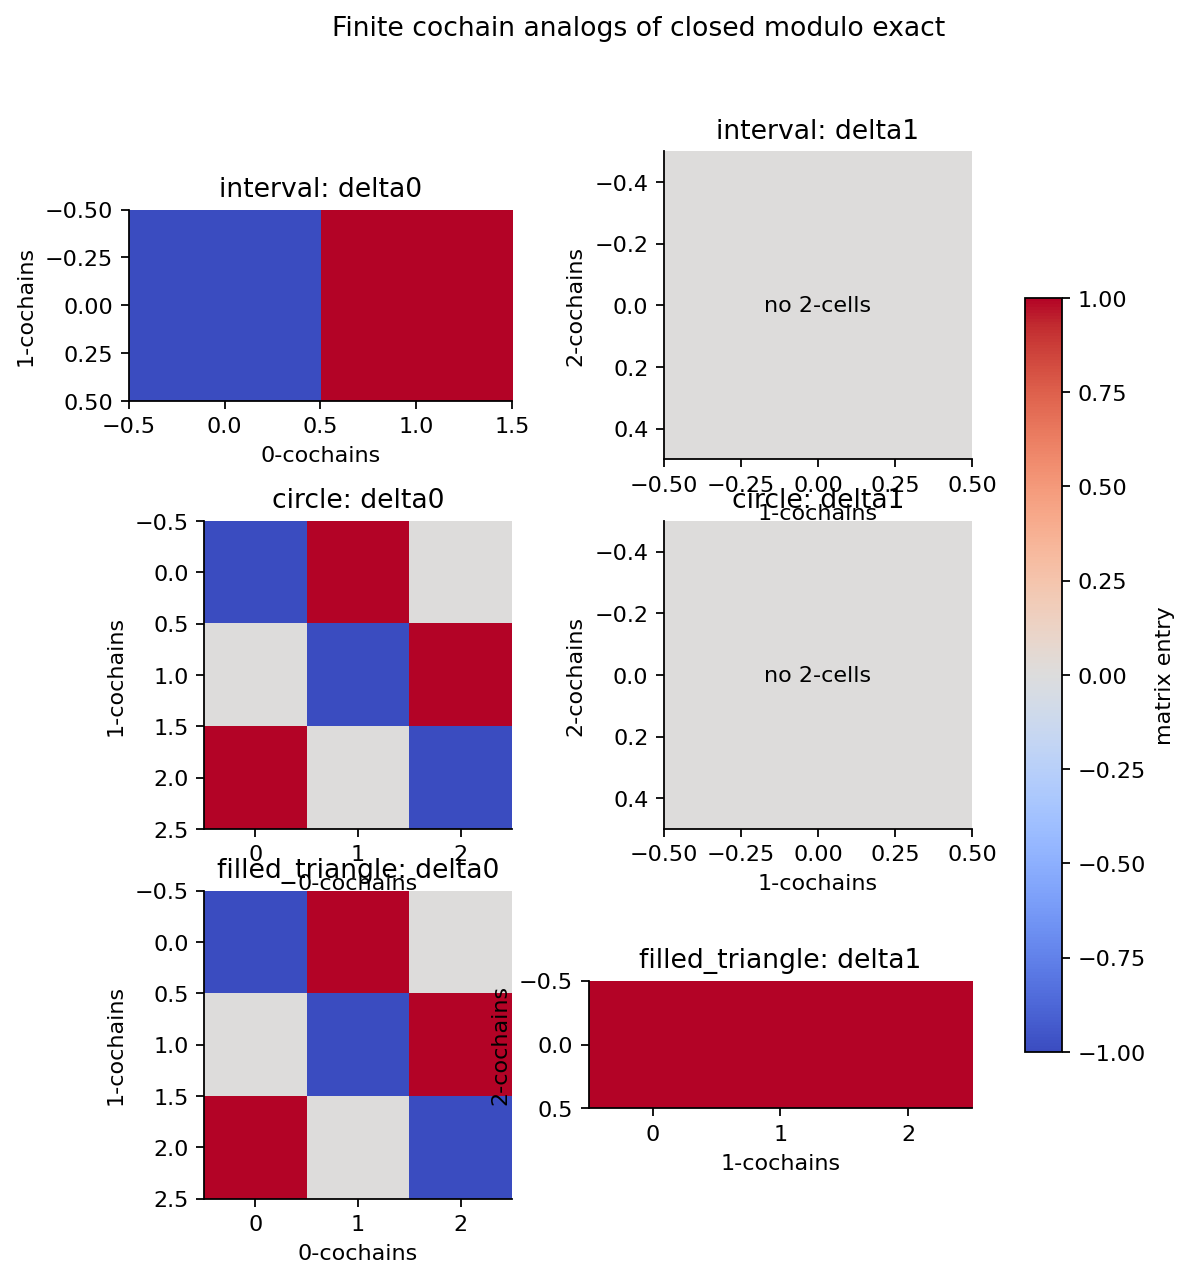

Betti table written to `artifacts\chapter-17-de-rham-cohomology\tables\finite-cochain-betti-models.csv`.

In [5]:
def rank(matrix: np.ndarray) -> int:
    if matrix.size == 0:
        return 0
    return int(np.linalg.matrix_rank(matrix.astype(float), tol=1e-10))

complexes = {
    "interval": {
        "d1": np.array([[-1], [1]], dtype=float),
        "d2": np.zeros((1, 0), dtype=float),
        "cells": (2, 1, 0),
    },
    "circle": {
        "d1": np.array([[-1, 0, 1], [1, -1, 0], [0, 1, -1]], dtype=float),
        "d2": np.zeros((3, 0), dtype=float),
        "cells": (3, 3, 0),
    },
    "filled_triangle": {
        "d1": np.array([[-1, 0, 1], [1, -1, 0], [0, 1, -1]], dtype=float),
        "d2": np.array([[1], [1], [1]], dtype=float),
        "cells": (3, 3, 1),
    },
}

betti_rows = []
fig, axes = plt.subplots(3, 2, figsize=(8.5, 8.5))
for row, (name, data) in enumerate(complexes.items()):
    d1 = data["d1"]
    d2 = data["d2"]
    n0, n1, n2 = data["cells"]
    r1 = rank(d1)
    r2 = rank(d2)
    b0 = n0 - r1
    b1 = n1 - r1 - r2
    b2 = n2 - r2
    betti_rows.append({"space": name, "b0": b0, "b1": b1, "b2": b2, "rank_boundary_1": r1, "rank_boundary_2": r2})

    delta0 = d1.T
    delta1 = d2.T
    ax0, ax1 = axes[row]
    im0 = ax0.imshow(delta0, cmap="coolwarm", vmin=-1, vmax=1)
    ax0.set_title(f"{name}: delta0")
    ax0.set_xlabel("0-cochains")
    ax0.set_ylabel("1-cochains")
    if delta1.size:
        ax1.imshow(delta1, cmap="coolwarm", vmin=-1, vmax=1)
    else:
        ax1.imshow(np.zeros((1, 1)), cmap="coolwarm", vmin=-1, vmax=1)
        ax1.text(0, 0, "no 2-cells", ha="center", va="center")
    ax1.set_title(f"{name}: delta1")
    ax1.set_xlabel("1-cochains")
    ax1.set_ylabel("2-cochains")
fig.colorbar(im0, ax=axes.ravel().tolist(), shrink=0.72, label="matrix entry")
fig.suptitle("Finite cochain analogs of closed modulo exact", y=0.98)
cochain_path = save_matplotlib(fig, FIGURES / "finite-cochain-closed-exact-models.png")
plt.close(fig)
artifacts.append(cochain_path)

betti_table = save_csv(betti_rows, TABLES / "finite-cochain-betti-models.csv")
artifacts.append(betti_table)
cochain_check = save_json(
    {
        "betti_rows": betti_rows,
        "circle_has_one_h1_generator": next(row for row in betti_rows if row["space"] == "circle")["b1"] == 1,
        "filled_triangle_kills_h1": next(row for row in betti_rows if row["space"] == "filled_triangle")["b1"] == 0,
    },
    CHECKS / "finite-cochain-closed-exact-models.json",
)
check_paths.append(cochain_check)
display_artifact(cochain_path, width=820)
display(Markdown(f"Betti table written to `{betti_table.relative_to(BOOK_ROOT)}`."))

## 5. Mayer-Vietoris On The Circle

Mayer-Vietoris is the chapter's main computation engine. For a circle covered by two contractible arcs `U` and `V`, the intersection has two connected components. The local pieces have no `H^1`, but the mismatch of constants on the two overlap components produces the global circle class through the connecting homomorphism.

The finite-rank calculation below mirrors the exact sequence in degree zero and one:

`0 -> H^0(S^1) -> H^0(U) + H^0(V) -> H^0(U cap V) -> H^1(S^1) -> 0`.

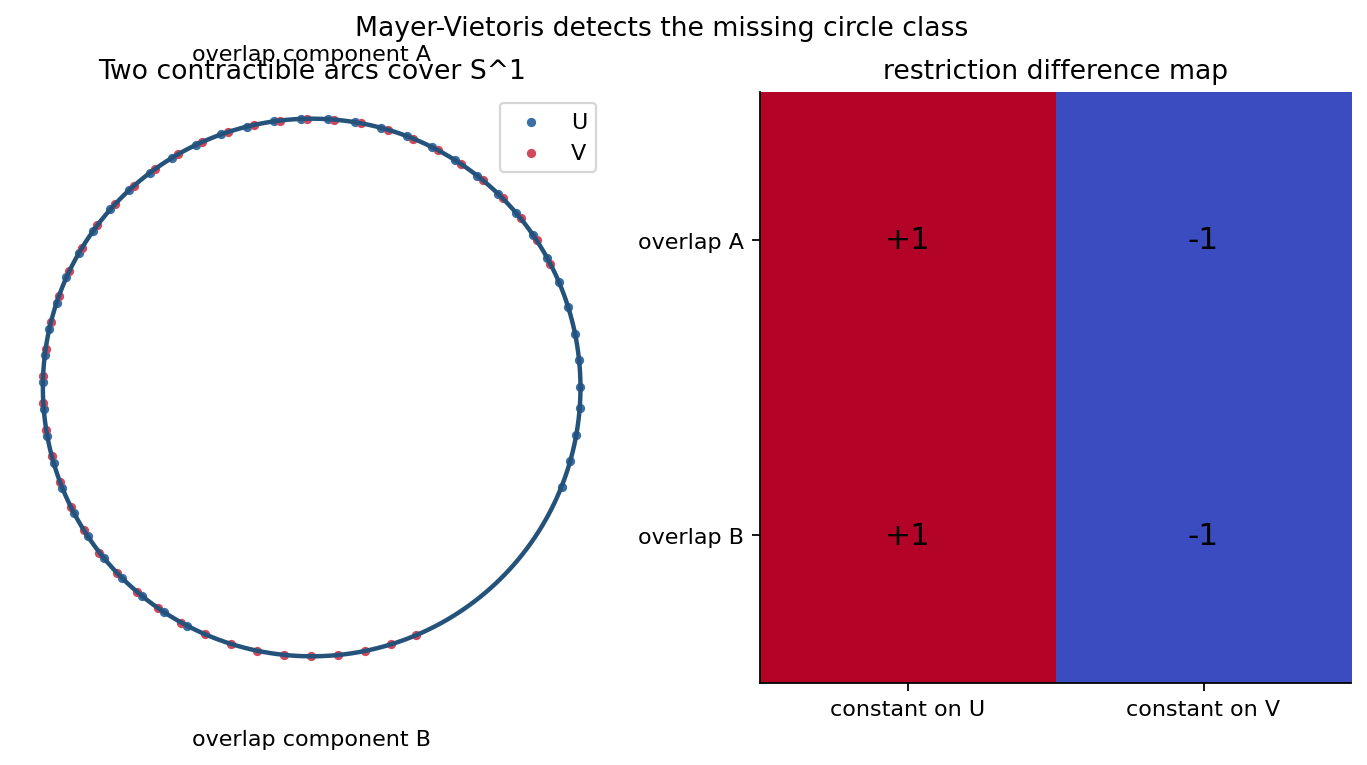

In [6]:
alpha = np.array([[1.0], [1.0]])             # H0(S1) -> H0(U)+H0(V)
beta = np.array([[1.0, -1.0], [1.0, -1.0]])  # restrictions to two overlap components
rank_alpha = rank(alpha)
rank_beta = rank(beta)
h0_s1_dim = 1
h0_uv_dim = 2
h0_overlap_dim = 2
h1_s1_from_cokernel = h0_overlap_dim - rank_beta

theta = np.linspace(0, 2 * np.pi, 500)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.8))
ax0.plot(np.cos(theta), np.sin(theta), color="#24527a", lw=2)
u_mask = (theta < 1.35 * np.pi) | (theta > 1.85 * np.pi)
v_mask = (theta > 0.15 * np.pi) & (theta < 1.65 * np.pi)
ax0.scatter(np.cos(theta[u_mask][::8]), np.sin(theta[u_mask][::8]), color="#3a6ea5", s=10, label="U")
ax0.scatter(np.cos(theta[v_mask][::8]), np.sin(theta[v_mask][::8]), color="#d1495b", s=10, label="V")
ax0.text(0, 1.22, "overlap component A", ha="center")
ax0.text(0, -1.33, "overlap component B", ha="center")
ax0.set_aspect("equal")
ax0.axis("off")
ax0.legend(loc="upper right")
ax0.set_title("Two contractible arcs cover S^1")

ax1.imshow(beta, cmap="coolwarm", vmin=-1, vmax=1)
for (i, j), value in np.ndenumerate(beta):
    ax1.text(j, i, f"{value:+.0f}", ha="center", va="center", fontsize=14)
ax1.set_xticks([0, 1], labels=["constant on U", "constant on V"])
ax1.set_yticks([0, 1], labels=["overlap A", "overlap B"])
ax1.set_title("restriction difference map")
fig.suptitle("Mayer-Vietoris detects the missing circle class")
mv_path = save_matplotlib(fig, FIGURES / "mayer-vietoris-circle-cover-ranks.png")
plt.close(fig)
artifacts.append(mv_path)

mv_check = save_json(
    {
        "rank_alpha": rank_alpha,
        "rank_beta": rank_beta,
        "h0_s1_dim": h0_s1_dim,
        "h0_uv_dim": h0_uv_dim,
        "h0_overlap_dim": h0_overlap_dim,
        "h1_s1_from_cokernel": h1_s1_from_cokernel,
        "exactness_dimension_check": h0_uv_dim - rank_alpha == rank_beta,
    },
    CHECKS / "mayer-vietoris-circle-cover-ranks.json",
)
check_paths.append(mv_check)
display_artifact(mv_path, width=920)

## 6. Top Degree, Compact Support, And Orientability

The chapter uses Mayer-Vietoris and the compact-support Poincare lemma to compute top-degree groups. The important distinctions are compact versus noncompact, orientable versus nonorientable, and ordinary versus compactly supported cohomology. The table below keeps the hypotheses visible; it is the kind of information that becomes easy to misuse if it is left only as a string of theorem names.

In [7]:
top_rows = [
    {
        "case": "connected oriented n-manifold",
        "group": "H_c^n(M)",
        "result": "R",
        "detector": "integration of compactly supported n-forms",
        "hypothesis_to_check": "orientation chosen; compact support allowed",
    },
    {
        "case": "compact connected orientable n-manifold",
        "group": "H_dR^n(M)",
        "result": "R",
        "detector": "integral of an orientation form",
        "hypothesis_to_check": "compactness converts compact support to ordinary forms",
    },
    {
        "case": "noncompact connected orientable n-manifold",
        "group": "H_dR^n(M)",
        "result": "0",
        "detector": "ordinary top forms become exact",
        "hypothesis_to_check": "noncompact exhaustion is used",
    },
    {
        "case": "connected nonorientable n-manifold",
        "group": "top ordinary and compact support",
        "result": "0",
        "detector": "orientation obstruction",
        "hypothesis_to_check": "no global orientation form exists",
    },
]
top_table = save_csv(top_rows, TABLES / "top-degree-cohomology-hypotheses.csv")
artifacts.append(top_table)
top_check = save_json({"rows": top_rows, "case_count": len(top_rows)}, CHECKS / "top-degree-cohomology-hypotheses.json")
check_paths.append(top_check)
display(Markdown(f"Top-degree hypothesis table written to `{top_table.relative_to(BOOK_ROOT)}`."))

Top-degree hypothesis table written to `artifacts\chapter-17-de-rham-cohomology\tables\top-degree-cohomology-hypotheses.csv`.

## 7. Degree Theory: Integration And Signed Preimages Agree

Once top-degree cohomology of compact oriented manifolds is understood, a smooth map `F: M -> N` between compact connected oriented `n`-manifolds has an integer degree. The degree can be recognized in two ways:

1. Pull back an `n`-form and compare integrals.
2. Count the preimages of a regular value with signs determined by whether the differential preserves orientation.

For `S^1 -> S^1`, `z -> z^k`, both definitions are easy to inspect. The pullback of the angular form multiplies by `k`, and a regular value has `|k|` preimages, each with sign `sign(k)`.

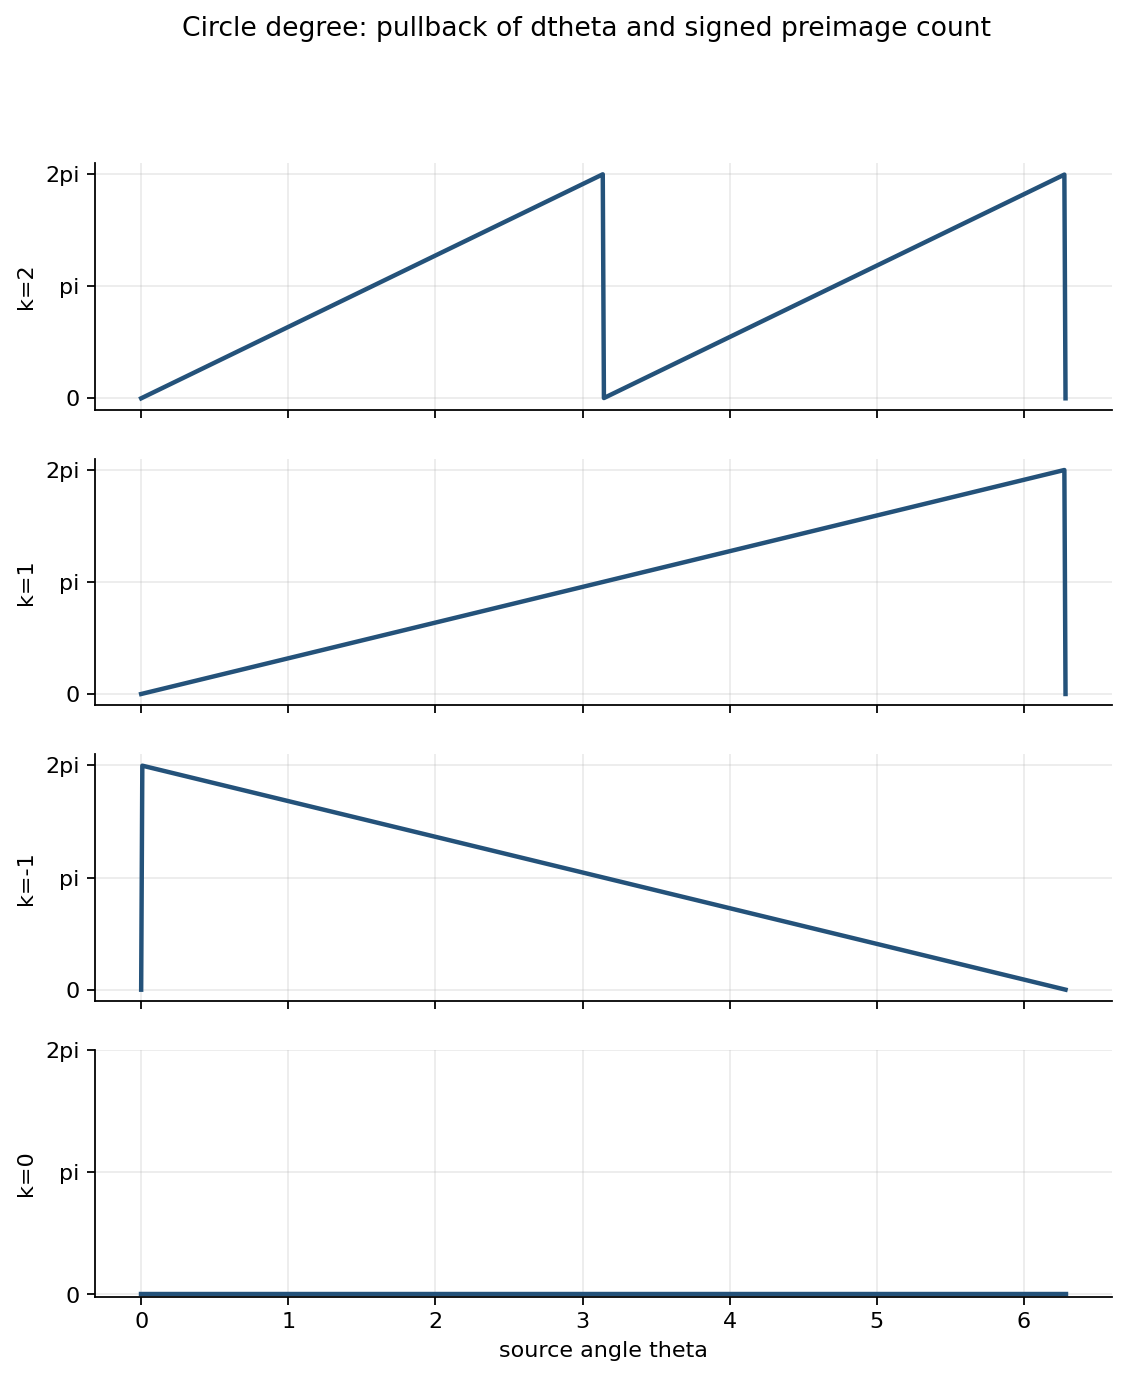

Degree table written to `artifacts\chapter-17-de-rham-cohomology\tables\circle-map-degree-checks.csv`.

In [8]:
degree_rows = []
ks = [2, 1, -1, 0]
fig, axes = plt.subplots(len(ks), 1, figsize=(8.2, 9.2), sharex=True)
theta = np.linspace(0, 2 * np.pi, 800)
for ax, k in zip(axes, ks):
    target_angle = (k * theta) % (2 * np.pi)
    ax.plot(theta, target_angle, color="#24527a", lw=2)
    ax.set_ylabel(f"k={k}")
    ax.set_yticks([0, np.pi, 2 * np.pi], labels=["0", "pi", "2pi"])
    ax.grid(alpha=0.25)
    integral_degree = k
    if k > 0:
        signed_count = k
        preimage_count = k
    elif k < 0:
        signed_count = k
        preimage_count = abs(k)
    else:
        signed_count = 0
        preimage_count = 0
    degree_rows.append(
        {
            "map": f"z -> z^{k}" if k != 0 else "constant map",
            "integral_degree": integral_degree,
            "regular_value_preimage_count": preimage_count,
            "signed_preimage_count": signed_count,
            "definitions_agree": integral_degree == signed_count,
        }
    )
axes[-1].set_xlabel("source angle theta")
fig.suptitle("Circle degree: pullback of dtheta and signed preimage count")
degree_path = save_matplotlib(fig, FIGURES / "circle-map-degree-integral-vs-preimages.png")
plt.close(fig)
artifacts.append(degree_path)

degree_table = save_csv(degree_rows, TABLES / "circle-map-degree-checks.csv")
artifacts.append(degree_table)
degree_check = save_json(
    {
        "rows": degree_rows,
        "all_definitions_agree": all(row["definitions_agree"] for row in degree_rows),
        "composition_sample_deg_z2_after_zminus1": 2 * -1,
    },
    CHECKS / "circle-map-degree-integral-vs-preimages.json",
)
check_paths.append(degree_check)
display_artifact(degree_path, width=820)
display(Markdown(f"Degree table written to `{degree_table.relative_to(BOOK_ROOT)}`."))

## Applied Lab

Use the cells above as a controlled lab for the chapter's hypotheses.

- Move the missing point out of the punctured-plane loop. The angular form still has local formulas, but the period around your chosen loop changes only when the loop winds around the hole.
- Replace the circle finite complex with the filled triangle. The 1-cycle is still visible, but the 2-cell turns it into a boundary, killing `H^1`.
- Change the two-arc cover of `S^1` so the intersection is connected. The rank calculation no longer has the extra overlap component needed to recover the circle generator.
- Change `k` in the circle degree model. The integral and signed-preimage definitions should change together, while a constant map has degree zero.

These experiments are deliberately small because the chapter's conceptual load is high. The aim is to keep every theorem tied to an object the learner can inspect: a form, a loop, a quotient, a cover, an orientation class, or a signed count.

## Final Sanity Checks

The checks below enforce chapter coverage, artifact integrity, and the main invariants. They do not prove the theorems, but they do guard against a stale or decorative notebook.

In [9]:
coverage_terms = [
    "de Rham complex",
    "closed",
    "exact",
    "pullback",
    "homotopy operator",
    "Poincare lemma",
    "Mayer-Vietoris",
    "compact support",
    "top-degree cohomology",
    "degree theory",
]

assert d_omega_coeff == 0
assert abs(loop_integral - 2 * np.pi) < 1e-3
assert sp.simplify(h_dg - endpoint_difference) == 0
assert next(row for row in betti_rows if row["space"] == "circle")["b1"] == 1
assert next(row for row in betti_rows if row["space"] == "filled_triangle")["b1"] == 0
assert h1_s1_from_cokernel == 1
assert all(row["definitions_agree"] for row in degree_rows)
assert_artifacts(artifacts + check_paths, min_bytes=64)

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 440-466",
    "coverage_terms": coverage_terms,
    "artifact_count": len(artifacts),
    "check_count": len(check_paths),
    "core_invariants": {
        "angular_form_closed": str(d_omega_coeff) == "0",
        "angular_period_is_2pi": abs(loop_integral - 2 * np.pi) < 1e-3,
        "homotopy_operator_test": bool(sp.simplify(h_dg - endpoint_difference) == 0),
        "circle_h1_dimension": int(h1_s1_from_cokernel),
        "degree_definitions_agree": all(row["definitions_agree"] for row in degree_rows),
    },
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
display(Markdown(f"Final sanity written to `{final_sanity_path.relative_to(BOOK_ROOT)}`."))
print("final_sanity passed for Chapter 17")

Final sanity written to `artifacts\chapter-17-de-rham-cohomology\checks\final_sanity.json`.

final_sanity passed for Chapter 17


## Takeaways

De Rham cohomology packages global obstructions to solving `d eta = omega`. Local exactness comes from the Poincare lemma, but global exactness is tested by loops, cycles, covers, and top-degree integration. Pullback makes cohomology functorial, and the homotopy operator explains why homotopic maps act the same on cohomology. Mayer-Vietoris is the main computation engine: it turns a cover with simple pieces into an exact sequence that exposes the missing global information. Degree theory is the payoff: the top cohomology class of a compact oriented manifold lets a smooth map carry a homotopy-invariant integer, visible either by integration or by signed preimage counts.